# Pneumonia Detection CNN Model

This notebook trains a CNN to classify chest X-rays into `NORMAL` vs `PNEUMONIA`.

In [50]:
import os
import sys
import json
import random
import pathlib
import subprocess

# Install optional dependencies if missing
for _pkg in ["keras-tuner"]:
    try:
        __import__(_pkg.replace("-", "_"))
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
import keras
import keras_tuner as kt

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

if "/content/drive/MyDrive/Colab Notebooks" not in sys.path:
    sys.path.append("/content/drive/MyDrive/Colab Notebooks")

try:
    from helpers import data_utils, model_utils, training_utils, visualization
except ModuleNotFoundError:
    for _p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
        if os.path.isdir(_p) and _p not in sys.path:
            sys.path.append(_p)
    from helpers import data_utils, model_utils, training_utils, visualization

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.19.0
Keras: 3.13.2


In [3]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [4]:
# Configuration
if USE_KAGGLE:
    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")
elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_WITHOUT_AUG_CHECKPOINT_PATH = SAVE_DIR / "baseline_without_aug_best_checkpoint.keras"
BASELINE_CHECKPOINT_PATH = SAVE_DIR / "baseline_best_checkpoint.keras"
TUNED_CHECKPOINT_PATH = SAVE_DIR / "baseline_tuned_best_checkpoint.keras"

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Model artifacts will be stored in: /content/drive/MyDrive/saved_models


## 1) Exploratory Data Analysis

Quickly inspect class counts, class balance per split, and a few raw samples before building the training pipeline.

In [6]:
split_counts = {
    "train": data_utils.count_images(TRAIN_DIR),
    "test": data_utils.count_images(TEST_DIR),
}
if os.path.isdir(VAL_DIR):
    split_counts["val"] = data_utils.count_images(VAL_DIR)

for split_name, c in split_counts.items():
    print(f"{split_name.upper()}: NORMAL={c['NORMAL']}, PNEUMONIA={c['PNEUMONIA']}, TOTAL={c['NORMAL'] + c['PNEUMONIA']}")

print("Note: original dataset/val images are merged into the training pool for stratified split.")

TRAIN: NORMAL=1341, PNEUMONIA=3875, TOTAL=5216
TEST: NORMAL=234, PNEUMONIA=390, TOTAL=624
VAL: NORMAL=8, PNEUMONIA=8, TOTAL=16
Note: original dataset/val images are merged into the training pool for stratified split.


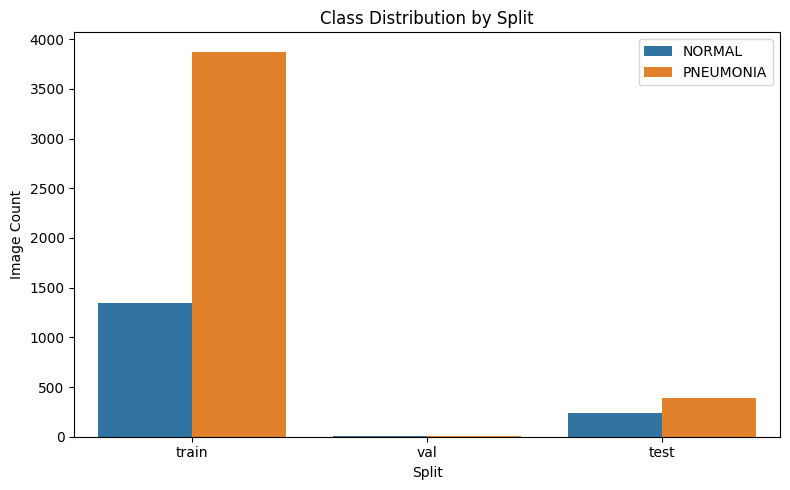

In [7]:
# Class distribution plot
dist_splits = []
dist_classes = []
dist_counts = []

for split_name in ["train", "val", "test"]:
    for class_name in ["NORMAL", "PNEUMONIA"]:
        dist_splits.append(split_name)
        dist_classes.append(class_name)
        dist_counts.append(split_counts[split_name][class_name])

plt.figure(figsize=(8, 5))
sns.barplot(x=dist_splits, y=dist_counts, hue=dist_classes)
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

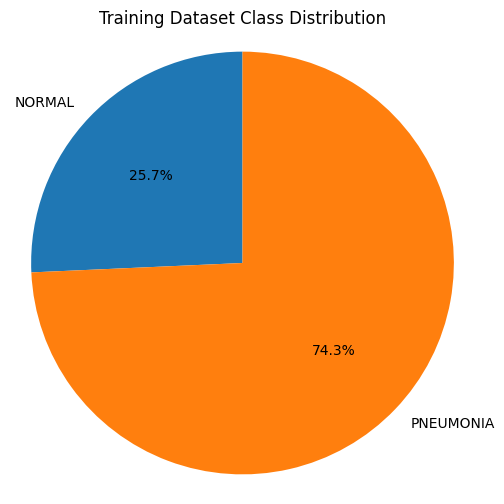

In [37]:
train_counts = split_counts["train"]

labels = list(train_counts.keys())   # ["NORMAL", "PNEUMONIA"]
sizes = list(train_counts.values()) # corresponding counts

plt.figure(figsize=(6, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Training Dataset Class Distribution")
plt.axis("equal")  # keep it circular
plt.show()

Observation:

- Extremely Small Validation Set: The validation dataset contains only 16 images. The validation set must then be reconstructed by splitting the training dataset.

- Severe Class Imbalance in training: The training dataset has approximately a 3:1 imbalance (Normal ≈ 26% and Pneumonia ≈ 74%) We must use class weighting and data augmentation to reduce class bias.

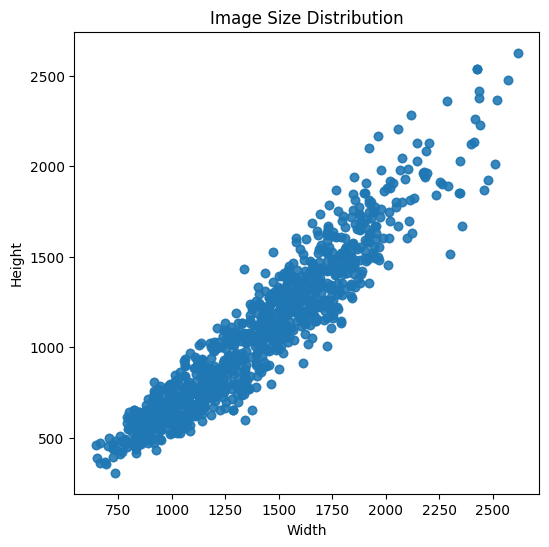

In [40]:
from PIL import Image

### Image Dimension Analysis

sizes = []

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)

    for img_file in os.listdir(folder)[:500]:

        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

# Plot size distribution
plt.figure(figsize=(6,6))

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

Images appear in multiple resolutions. For modelling our CNN, we will resized them into a constant size of 224 x 224 to enhance model performance and training efficiency

In [45]:
### Check whether images are RGB or grayscale

splits = {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR
}

classes = ["NORMAL", "PNEUMONIA"]

for split, path in splits.items():
    for cls in ["NORMAL", "PNEUMONIA"]:
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        print(split, cls, img.mode)

train NORMAL L
train PNEUMONIA L
val NORMAL L
val PNEUMONIA L
test NORMAL L
test PNEUMONIA L


Images are all grayscales images

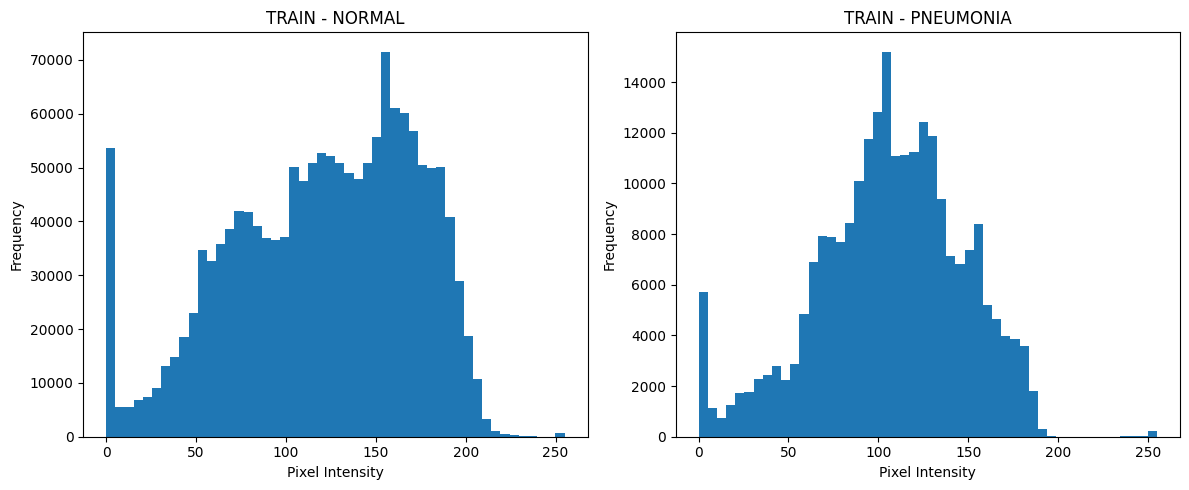

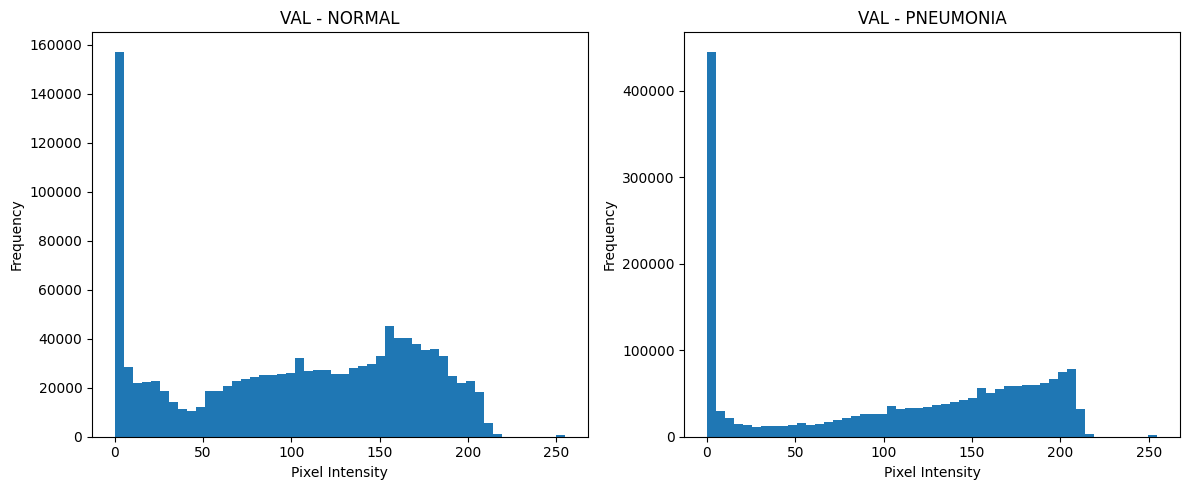

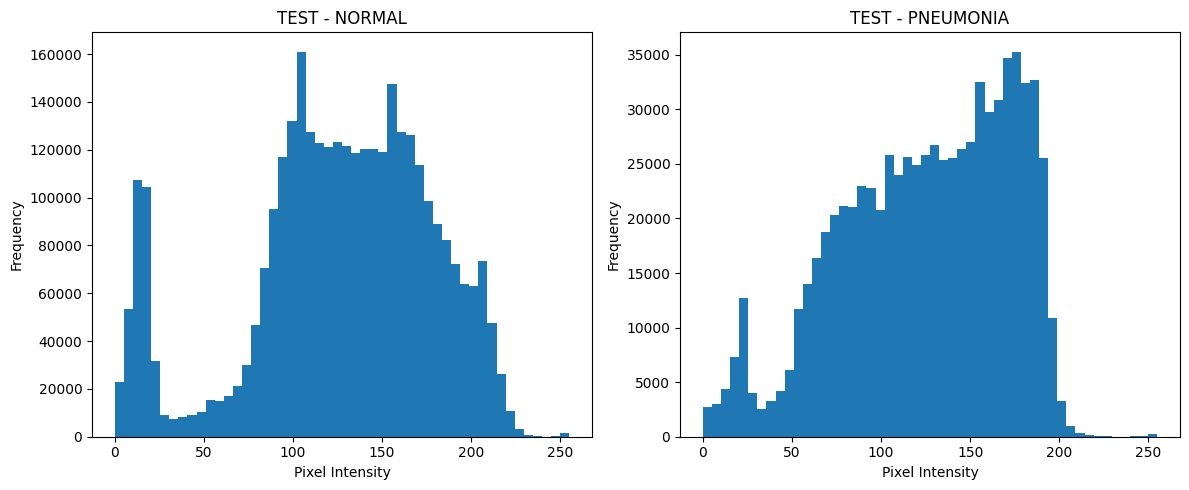

In [46]:
for split, path in splits.items():
    plt.figure(figsize=(12, 5))  # wider figure for side-by-side plots

    for i, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        # Load first image of each class
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        img_array = np.array(img)

        # Plot side by side
        plt.subplot(1, 2, i + 1)
        plt.hist(img_array.flatten(), bins=50)
        plt.title(f"{split.upper()} - {cls}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Images values are typically range between 0 – 255. Pixel values will be normalized to [0,1] during preprocessing.

In [47]:
corrupted = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            try:
                img = Image.open(path_img)
                img.verify()

            except:
                corrupted.append(path_img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


There is 0 corruped images

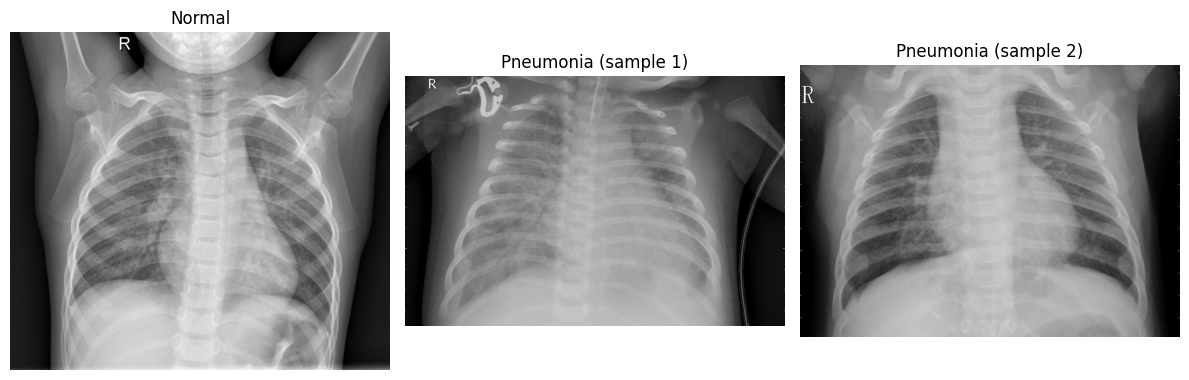

In [8]:
# Visualize sample images from each class in train split
train_normal_dir = os.path.join(TRAIN_DIR, "NORMAL")
train_pneumonia_dir = os.path.join(TRAIN_DIR, "PNEUMONIA")

valid_image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

normal_samples = sorted(
    f for f in os.listdir(train_normal_dir)
    if f.lower().endswith(valid_image_exts)
)[:3]
pneumonia_samples = sorted(
    f for f in os.listdir(train_pneumonia_dir)
    if f.lower().endswith(valid_image_exts)
)[:3]

sample_paths = [
    os.path.join(train_normal_dir, normal_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[0]),
    os.path.join(train_pneumonia_dir, pneumonia_samples[1]),
]

titles = ["Normal", "Pneumonia (sample 1)", "Pneumonia (sample 2)"]

plt.figure(figsize=(12, 4))
for i, (path, title) in enumerate(zip(sample_paths, titles), start=1):
    img = keras.utils.load_img(path, color_mode="grayscale")
    arr = keras.utils.img_to_array(img)
    plt.subplot(1, 3, i)
    plt.imshow(arr.squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Check a few raw image shapes (pick first readable image per class)
valid_image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

shape_samples = []
for class_name, class_dir in [("NORMAL", train_normal_dir), ("PNEUMONIA", train_pneumonia_dir)]:
    candidate_files = sorted(
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_image_exts)
    )

    selected = None
    for sample_file in candidate_files:
        sample_path = os.path.join(class_dir, sample_file)
        try:
            img = keras.utils.load_img(sample_path)
            selected = (class_name, sample_file, img.size)
            break
        except Exception:
            continue

    if selected is None:
        print(f"{class_name}: no readable image file found in {class_dir}")
    else:
        shape_samples.append(selected)  # PIL size = (width, height)

for class_name, file_name, size in shape_samples:
    print(f"{class_name}: {file_name} -> original size (W,H) = {size}")
print(f"Target resize: {IMG_SIZE}")

NORMAL: IM-0115-0001.jpeg -> original size (W,H) = (2090, 1858)
PNEUMONIA: person1000_bacteria_2931.jpeg -> original size (W,H) = (1152, 760)
Target resize: (224, 224)


## 2) Data Loading and Preprocessing

Create stratified train/validation splits and build `tf.data` pipelines with balanced on-the-fly sampling.

In [10]:
# Collect all file paths and labels from train plus optional original val directory
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    VAL_DIR,
)

print(f"Source pool size (train + optional original val): {len(all_train_paths)} images")

Source pool size (train + optional original val): 5232 images


In [11]:
# Build train/val/test datasets from helper
train_ds, val_ds, test_ds, dataset_meta = data_utils.build_train_val_test_datasets(
    train_paths=all_train_paths,
    train_labels=all_train_labels,
    test_paths=test_paths,
    test_labels=test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    preprocess_fn=None,
    autotune=AUTOTUNE,
)

train_paths = dataset_meta["train_paths"]
train_labels_raw = dataset_meta["train_labels_raw"]
val_paths = dataset_meta["val_paths"]
val_labels_arr = dataset_meta["val_labels"]
normal_count = dataset_meta["normal_count"]
pneumonia_count = dataset_meta["pneumonia_count"]
steps_per_epoch = dataset_meta["steps_per_epoch"]

print(f"Stratified split (before balancing): {len(train_paths)} train, {len(val_paths)} val")
print(f"  Train before -> NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")
print(f"  Val          -> NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}")
print(f"  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch")
print(f"  Steps per epoch: {steps_per_epoch}")

class_names = ["NORMAL", "PNEUMONIA"]
print("Class names:", class_names)
print("Note: dataset/val folder excluded; validation split is stratified from dataset/train.")

Stratified split (before balancing): 4708 train, 524 val
  Train before -> NORMAL=1214, PNEUMONIA=3494
  Val          -> NORMAL=135, PNEUMONIA=389
  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch
  Steps per epoch: 148
Class names: ['NORMAL', 'PNEUMONIA']
Note: dataset/val folder excluded; validation split is stratified from dataset/train.


In [12]:
# Augmentation layers
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

In [13]:
# Performance optimization for tf.data pipelines
# train_ds is infinite (repeat + sample_from_datasets), so we only prefetch.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")

Datasets are ready.


## 2.1) Oversampling and Augmentation Checks

Validate that the balanced sampling strategy and augmentation pipeline are behaving as expected.

Class distribution check
  Train before balancing: NORMAL=1214, PNEUMONIA=3494
  Train after balancing : NORMAL~2368, PNEUMONIA~2368 (sampled)
  Validation            : NORMAL=135, PNEUMONIA=389


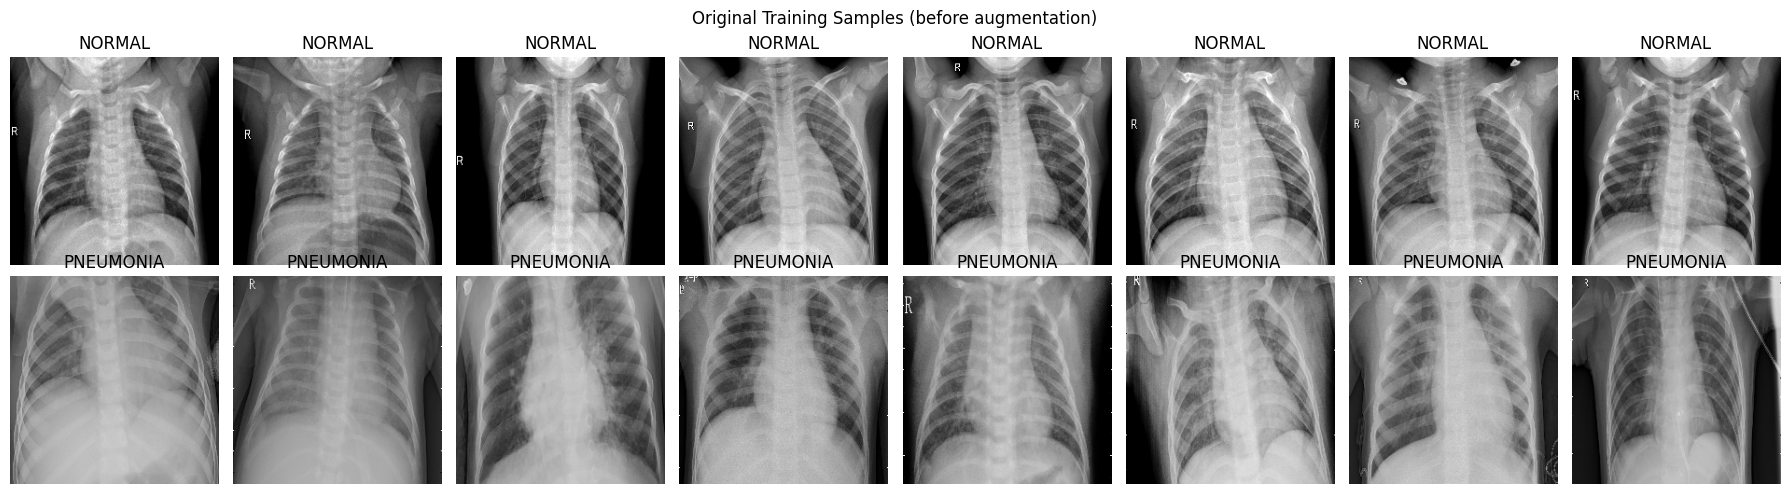

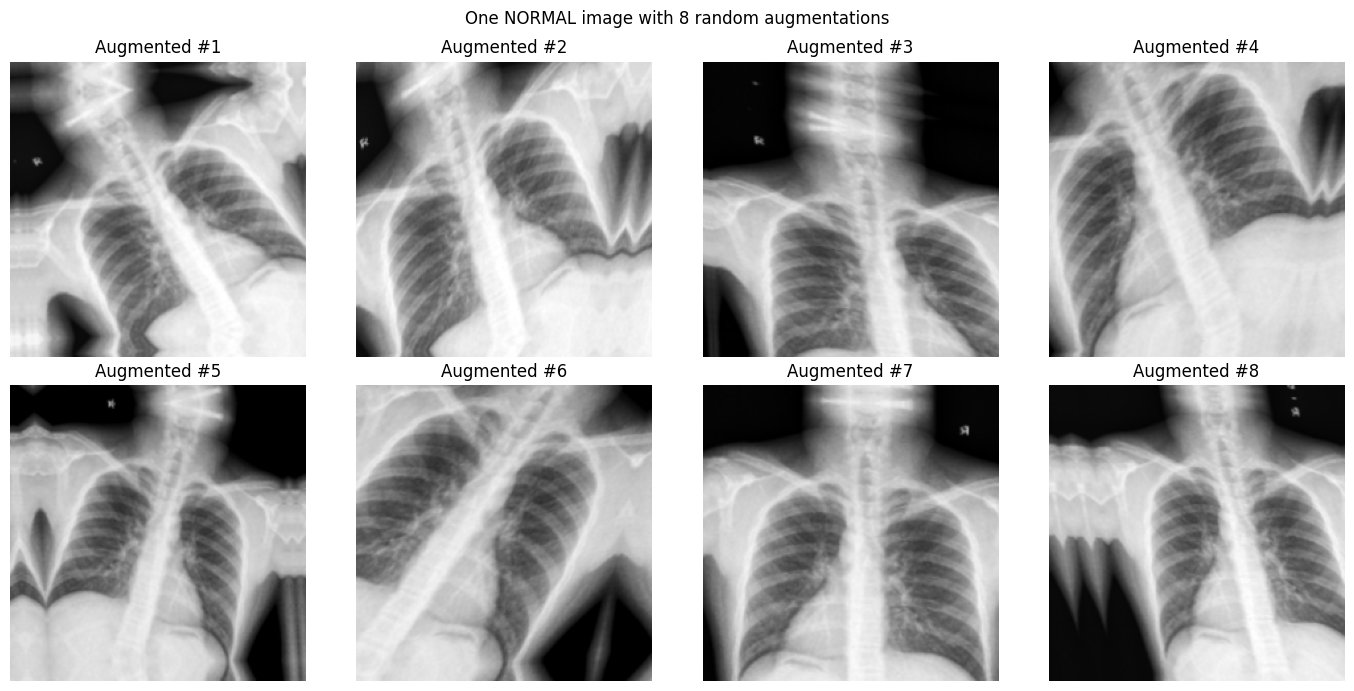

In [14]:
normal_paths = train_paths[train_labels_raw == 0]
pneumonia_paths = train_paths[train_labels_raw == 1]

# For diagnostics only: effective per-epoch class counts under 1:1 sampled training.
balanced_epoch_count = steps_per_epoch * BATCH_SIZE // 2

print("Class distribution check")
print(f"  Train before balancing: NORMAL={(train_labels_raw==0).sum()}, PNEUMONIA={(train_labels_raw==1).sum()}")
print(f"  Train after balancing : NORMAL~{balanced_epoch_count}, PNEUMONIA~{balanced_epoch_count} (sampled)")
print(f"  Validation            : NORMAL={(val_labels_arr==0).sum()}, PNEUMONIA={(val_labels_arr==1).sum()}")

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
normal_sample_paths = rng.choice(normal_paths, size=min(8, len(normal_paths)), replace=False)
pneumonia_sample_paths = rng.choice(pneumonia_paths, size=min(8, len(pneumonia_paths)), replace=False)

for i in range(8):
    if i < len(normal_sample_paths):
        img = keras.utils.load_img(normal_sample_paths[i], target_size=IMG_SIZE)
        axes[0, i].imshow(img)
        axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

    if i < len(pneumonia_sample_paths):
        img = keras.utils.load_img(pneumonia_sample_paths[i], target_size=IMG_SIZE)
        axes[1, i].imshow(img)
        axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.suptitle("Original Training Samples (before augmentation)")
plt.tight_layout()
plt.show()

sample_normal = keras.utils.load_img(normal_paths[0], target_size=IMG_SIZE)
sample_tensor = tf.expand_dims(tf.cast(keras.utils.img_to_array(sample_normal), tf.float32), axis=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in enumerate(axes.flat):
    aug_img = data_augmentation(sample_tensor, training=True)[0]
    aug_img = tf.clip_by_value(aug_img / 255.0, 0.0, 1.0)
    ax.imshow(aug_img)
    ax.set_title(f"Augmented #{idx+1}")
    ax.axis("off")

plt.suptitle("One NORMAL image with 8 random augmentations")
plt.tight_layout()
plt.show()

## 3) Helper Utilities

Define reusable serialization and metadata-saving helpers before training and evaluation.

In [15]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)

## 4) CNN Model Without Augmentation Architecture

Define a regularized baseline CNN without in-graph augmentation and image rescaling for stable training.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)
model_without_aug = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=None,
    learning_rate=1e-2,
    l2_reg=1e-4,
    name="baseline_pneumonia_cnn",
)
model_without_aug.summary()

Model: "baseline_pneumonia_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 28, 28, 256)    │         1,02

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [54]:
my_callbacks_no_aug = training_utils.get_training_callbacks(
    checkpoint_path=BASELINE_WITHOUT_AUG_CHECKPOINT_PATH,
    patience=5,
    monitor="val_auc",
)

class_weight = {0: 1.0, 1: 4.0}
print("Class weights:", class_weight)

history_model_without_aug = model_without_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=my_callbacks_no_aug,
    class_weight=class_weight,
)

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 48s 157ms/step - accuracy: 0.8424 - auc: 0.9153 - loss: 0.4195 - pr_auc: 0.9659 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 17.5750 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8993 - auc: 0.9623 - loss: 0.2910 - pr_auc: 0.9857 - val_accuracy: 0.7634 - val_auc: 0.9075 - val_loss: 0.7422 - val_pr_auc: 0.9587 - learning_rate: 0.0100
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9237 - auc: 0.9749 - loss: 0.2445 - pr_auc: 0.9905 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 2.3088 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9314 - auc: 0.9791 - loss: 0.2266 - pr_auc: 0.9925 - val_accuracy: 0.7424 - val_auc: 0.5667 - val_loss: 1.8162 - val_pr_auc: 0.7688 - learning_rate: 0.0100
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 

## Evaluation of Model Without Augmentation

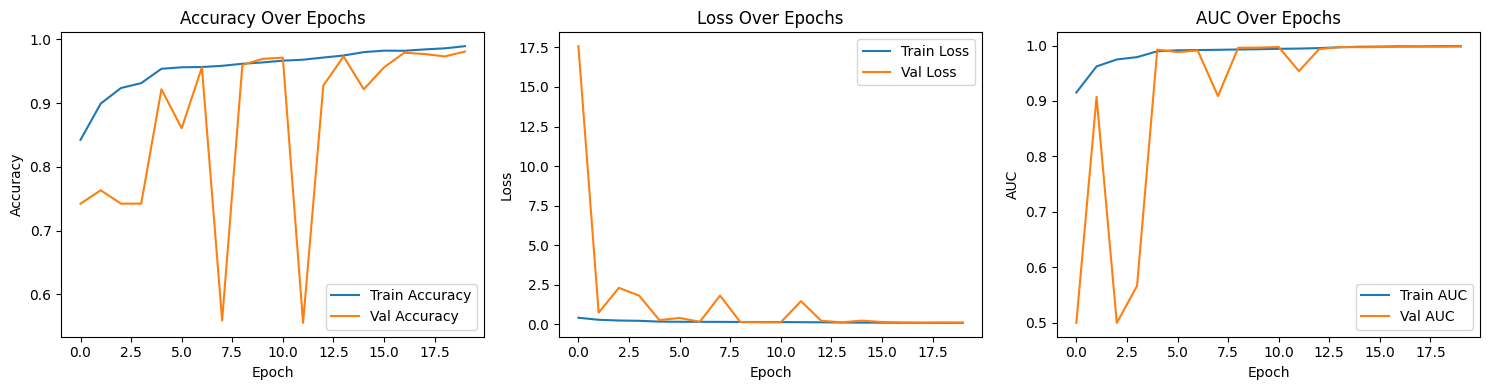

In [56]:
# Plot training curves (loss, accuracy, and AUC)
if history_model_without_aug is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history_model_without_aug.history["accuracy"], label="Train Accuracy")
    plt.plot(history_model_without_aug.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history_model_without_aug.history["loss"], label="Train Loss")
    plt.plot(history_model_without_aug.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history_model_without_aug.history["auc"], label="Train AUC")
    plt.plot(history_model_without_aug.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [57]:
best_model_without_aug = training_utils.load_model_compat(BASELINE_WITHOUT_AUG_CHECKPOINT_PATH)
print(f"Loaded best model from: {BASELINE_WITHOUT_AUG_CHECKPOINT_PATH}")

In [58]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [59]:
# Threshold tuning on validation split (PNEUMONIA F1)
best_threshold_no_aug, best_f1_no_aug, _, _ = training_utils.tune_threshold(
    best_model_without_aug, val_ds
)
print(f"Best threshold (PNEUMONIA F1): {best_threshold_no_aug:.2f}  |  Best F1: {best_f1_no_aug:.4f}")

Best threshold from validation split (macro F1): 0.46


Test ROC-AUC: 0.9150


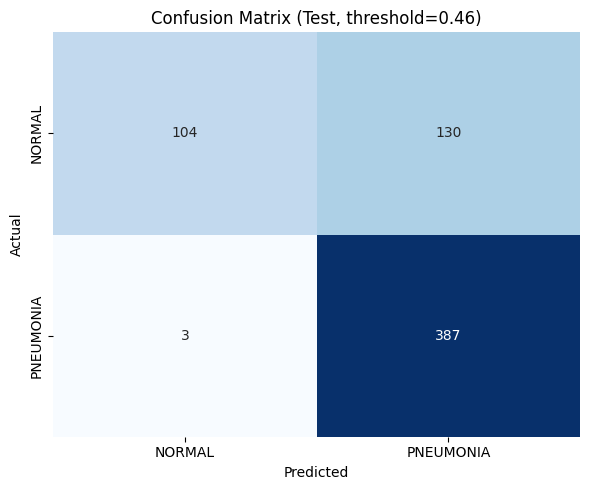

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.97      0.44      0.61       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.73       624
weighted avg       0.83      0.79      0.76       624



In [60]:
# Evaluate on test set
metrics_no_aug, report_no_aug, y_true, y_prob, y_pred = training_utils.evaluate_model(
    best_model_without_aug, test_ds, best_threshold_no_aug
)
test_roc_auc = metrics_no_aug["auc"]
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – No Aug (threshold={best_threshold_no_aug:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

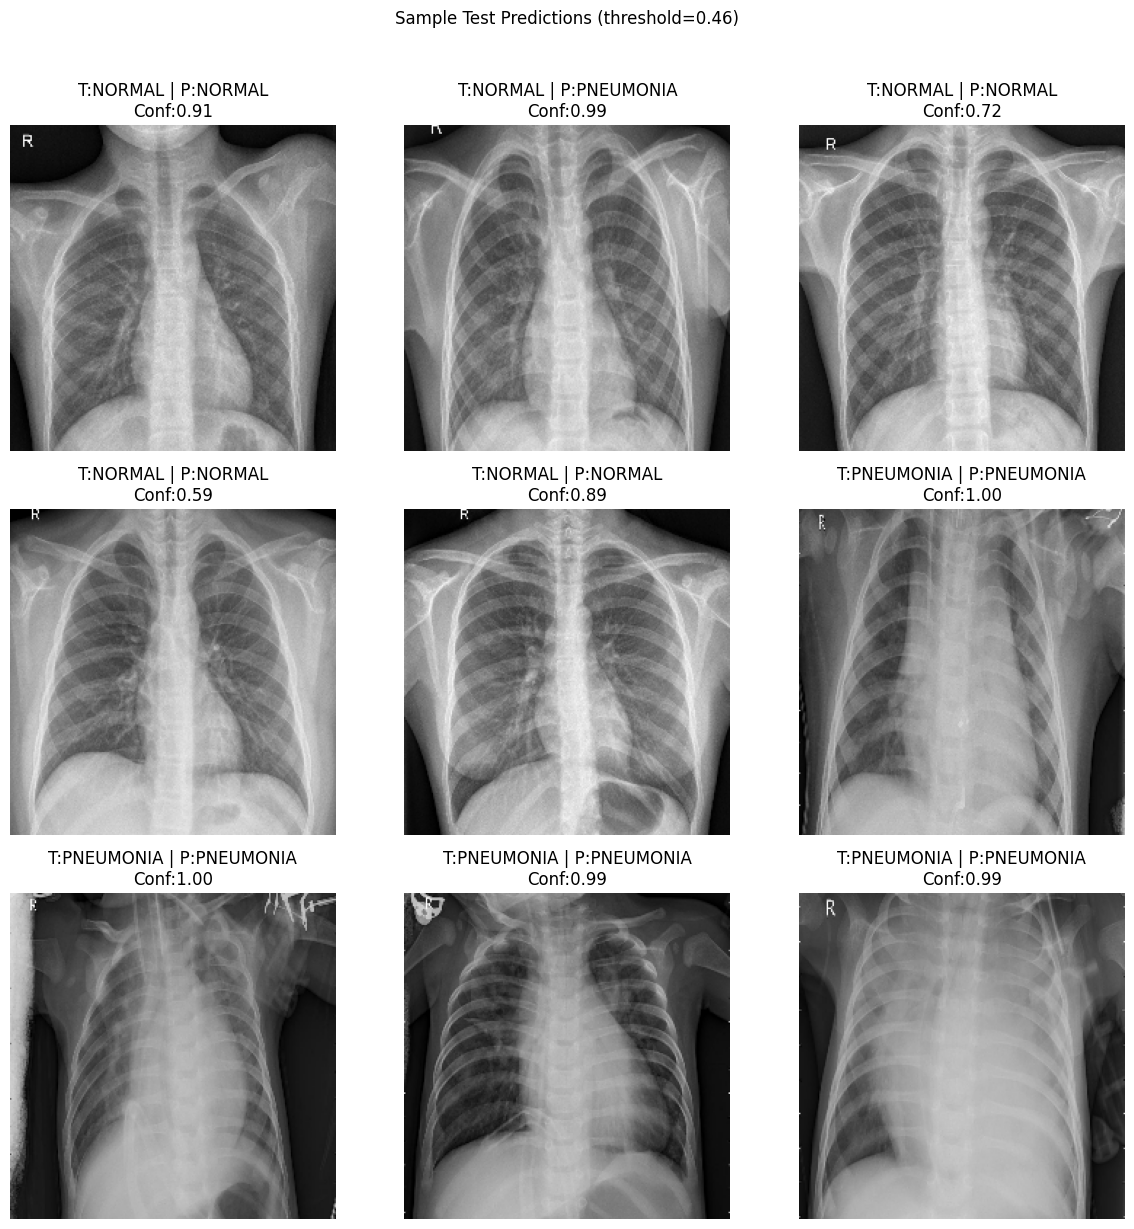

In [63]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = best_model_without_aug.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4) CNN Model Architecture

Define a regularized baseline CNN with in-graph augmentation and image rescaling for stable training.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)
model = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    learning_rate=1e-2,
    l2_reg=1e-4,
    name="pneumonia_cnn",
)
model.summary()

Model: "pneumonia_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 5) Compile Model

Compile the baseline model with robust classification metrics and gradient clipping for better optimization stability.

In [17]:
print("Balanced training split distribution (sampled):")
print(f"  NORMAL~{steps_per_epoch * BATCH_SIZE // 2}, PNEUMONIA~{steps_per_epoch * BATCH_SIZE // 2}, TOTAL~{steps_per_epoch * BATCH_SIZE}")
print("Validation split distribution:")
print(f"  NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}, TOTAL={len(val_labels_arr)}")

print("Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.")

Balanced training split distribution (sampled):
  NORMAL~2368, PNEUMONIA~2368, TOTAL~4736
Validation split distribution:
  NORMAL=135, PNEUMONIA=389, TOTAL=524
Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.


## 6) Train the CNN

Train with callbacks (early stopping, LR schedule, checkpointing) and resume from checkpoint when available.

In [18]:
my_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=BASELINE_CHECKPOINT_PATH,
    patience=5,
    monitor="val_auc",
)

class_weight = {0: 1.0, 1: 4.0}
print("Class weights:", class_weight)

if BASELINE_CHECKPOINT_PATH.exists():
    print(f"Loading existing baseline checkpoint: {BASELINE_CHECKPOINT_PATH}")
    model = training_utils.load_model_compat(BASELINE_CHECKPOINT_PATH)
    history = None
else:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks,
        class_weight=class_weight,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_CHECKPOINT_PATH}")

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.7528 - auc: 0.8472 - loss: 0.5295 - pr_auc: 0.9414 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 9.1540 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8256 - auc: 0.9057 - loss: 0.4189 - pr_auc: 0.9647 - val_accuracy: 0.7424 - val_auc: 0.5889 - val_loss: 1.8565 - val_pr_auc: 0.7780 - learning_rate: 0.0100
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8432 - auc: 0.9192 - loss: 0.3879 - pr_auc: 0.9697 - val_accuracy: 0.8378 - val_auc: 0.9520 - val_loss: 0.4787 - val_pr_auc: 0.9777 - learning_rate: 0.0100
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8452 - auc: 0.9298 - loss: 0.3594 - pr_auc: 0.9747 - val_accuracy: 0.8225 - val_auc: 0.8910 - val_loss: 0.5748 - val_pr_auc: 0.9450 - learning_rate: 0.0100
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 60

## 7) Evaluate and Visualize Results

Load the best checkpoint, tune decision threshold on validation data, and report test-set performance.

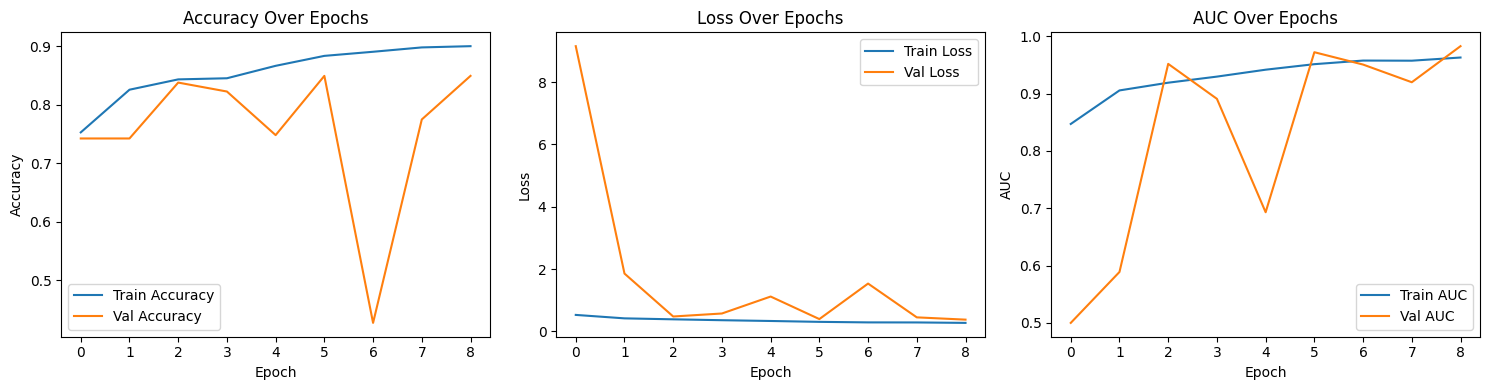

In [19]:
# Plot training curves (loss, accuracy, and AUC)
if history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history["auc"], label="Train AUC")
    plt.plot(history.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [20]:
# Baseline checkpoint loading stage
print("Loading baseline checkpoint for threshold tuning and test evaluation...")

Loading baseline checkpoint for threshold tuning and test evaluation...


In [21]:
if not BASELINE_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Model file not found at {BASELINE_CHECKPOINT_PATH}. Run training first."
    )
best_model = training_utils.load_model_compat(BASELINE_CHECKPOINT_PATH)
print(f"Loaded model from: {BASELINE_CHECKPOINT_PATH}")
print(f"Model input shape: {best_model.input_shape}")
print(f"Model output shape: {best_model.output_shape}")

Loaded model from: /content/drive/MyDrive/saved_models/baseline_best_checkpoint.keras
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)


In [22]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [23]:
# Threshold tuning on validation split (PNEUMONIA F1)
best_threshold, best_f1_val, _, _ = training_utils.tune_threshold(best_model, val_ds)
print(f"Best threshold (PNEUMONIA F1): {best_threshold:.2f}  |  Best F1: {best_f1_val:.4f}")

Best threshold from validation split (macro F1): 0.07


Test ROC-AUC: 0.9168


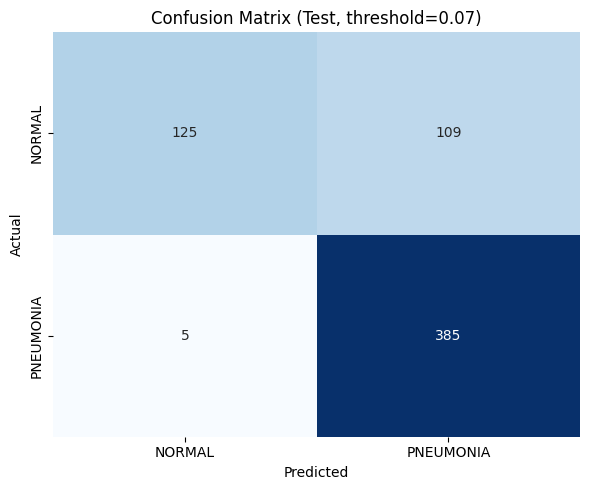

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.96      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



In [24]:
# Evaluate on test set
baseline_metrics_dict, baseline_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    best_model, test_ds, best_threshold
)
test_roc_auc = baseline_metrics_dict["auc"]
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test, threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

In [25]:
# Persist baseline model artifacts and metadata
baseline_hyperparams = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "class_weight": class_weight,
    "balanced_sampling": "sample_from_datasets(weights=[0.5, 0.5])",
    "steps_per_epoch": steps_per_epoch,
}

if "history" not in globals():
    history = None

save_model_with_meta(
    best_model, "baseline_cnn", baseline_metrics_dict, history,
    baseline_hyperparams, best_threshold
)

print(f"Baseline CNN saved with threshold={best_threshold:.2f}")
print(f"  Accuracy : {baseline_metrics_dict['accuracy']:.4f}")
print(f"  AUC      : {baseline_metrics_dict['auc']:.4f}")
print(f"  Precision: {baseline_metrics_dict['precision']:.4f}")
print(f"  Recall   : {baseline_metrics_dict['recall']:.4f}")
print(f"  F1       : {baseline_metrics_dict['f1']:.4f}")

Saved model to: /content/drive/MyDrive/saved_models/baseline_cnn.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_cnn_meta.json

Summary:
- Validation now uses a large split from dataset/train instead of the tiny val folder.
- Training uses balanced on-the-fly sampling with repeat + sample_from_datasets.
- Decision threshold tuned on validation split before final test evaluation.


NORMAL samples: 234 | PNEUMONIA samples: 390


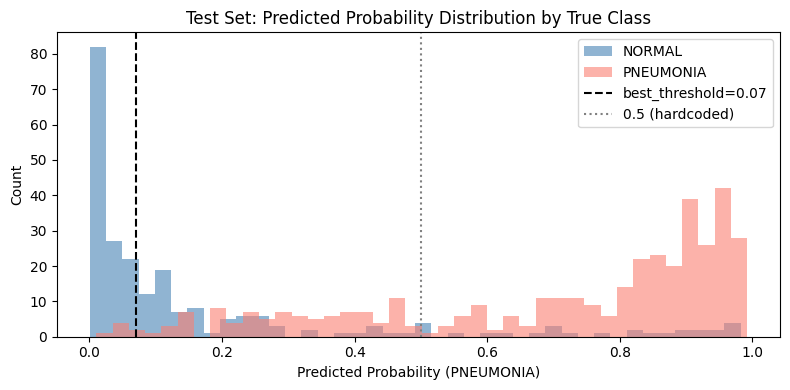

In [26]:
# Diagnostic: probability distribution by true class on test set
from IPython.display import display

# Flatten to 1D arrays to avoid shape/indexing edge cases.
y_true_arr = np.asarray(y_true).reshape(-1)
y_prob_arr = np.asarray(y_prob).reshape(-1)

normal_probs = y_prob_arr[y_true_arr == 0]
pneumonia_probs = y_prob_arr[y_true_arr == 1]

print(f"NORMAL samples: {normal_probs.size} | PNEUMONIA samples: {pneumonia_probs.size}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_probs, bins=40, alpha=0.6, label="NORMAL", color="steelblue")
ax.hist(pneumonia_probs, bins=40, alpha=0.6, label="PNEUMONIA", color="salmon")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"best_threshold={best_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="0.5 (hardcoded)")
ax.set_xlabel("Predicted Probability (PNEUMONIA)")
ax.set_ylabel("Count")
ax.set_title("Test Set: Predicted Probability Distribution by True Class")
ax.legend()
fig.tight_layout()

display(fig)
plt.close(fig)

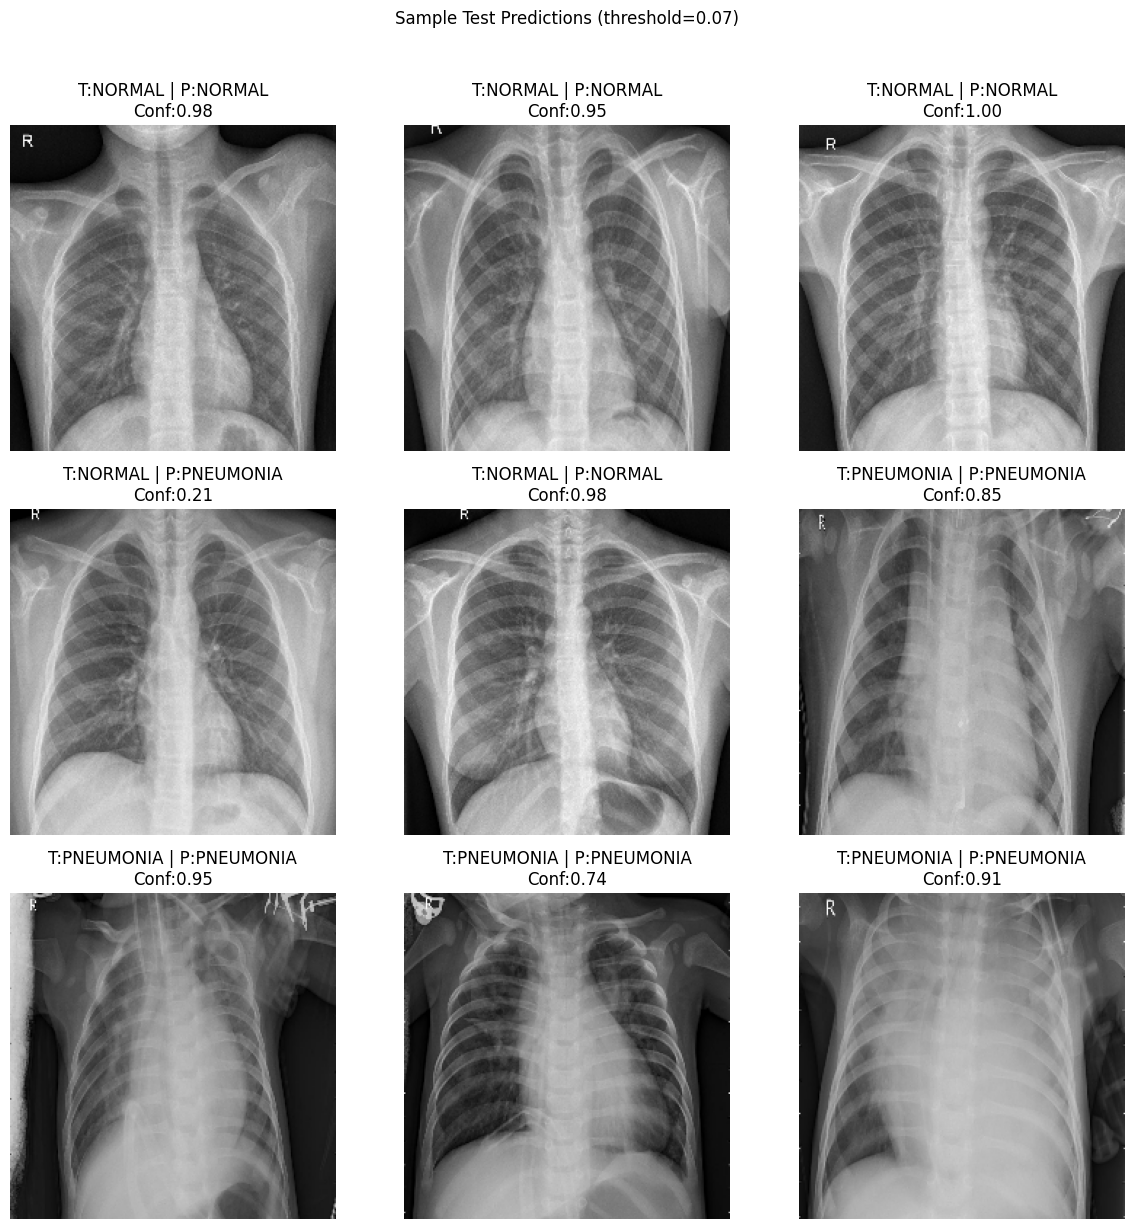

In [27]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = best_model.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8) Overfitting Countermeasures Used

1. Medically safe data augmentation (`RandomFlip`, mild `RandomRotation`, mild `RandomTranslation`, mild `RandomZoom`, mild `RandomShear`, mild `RandomBrightness`).
2. Batch normalization after each convolution block.
3. Progressive dropout in conv blocks plus classifier dropout.
4. L2 regularization in convolution and dense layers.
5. Gradient clipping (`clipnorm=1.0`) in Adam optimizer.
6. Conservative optimizer settings (`learning_rate=0.001`, `label_smoothing=0.02`) for smoother convergence.
7. Early stopping and LR scheduling on `val_accuracy`.

## 9) Baseline CNN Hyperparameter Tuning (Keras Tuner)

Search for better hyperparameters with Bayesian optimization, then train/evaluate the best tuned model.

In [28]:
MAX_TRIALS = 15
TUNER_EPOCHS = 12
TUNER_SEED = 42

class_weight = {0: 1.0, 1: 4.0}


def _load_image_for_tuning(path, label):
    return data_utils.load_image(path, label, IMG_SIZE)


# Build once, then only re-batch per trial to avoid remapping/reloading images.
_train_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels_raw.astype("float32")))
    .shuffle(len(train_paths), seed=TUNER_SEED, reshuffle_each_iteration=True)
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)
_val_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)


def _rebatch_trial_datasets(batch_size):
    train_ds_trial = _train_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds_trial = _val_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds_trial, val_ds_trial


def build_tunable_model(hp):
    return model_utils.build_baseline_model_from_hp(
        hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )


class PneumoniaTuner(kt.BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        batch_size = hp.Choice("batch_size", [16, 32, 48])

        train_ds_trial, val_ds_trial = _rebatch_trial_datasets(batch_size)
        trial_steps = max(1, int(np.ceil(len(train_paths) / batch_size)))

        trial_callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=3,
                restore_best_weights=True,
            )
        ]

        kwargs.update(
            {
                "x": train_ds_trial,
                "validation_data": val_ds_trial,
                "epochs": TUNER_EPOCHS,
                "steps_per_epoch": trial_steps,
                "callbacks": trial_callbacks,
                "class_weight": class_weight,
                "verbose": 1,
            }
        )
        return super().run_trial(trial, *args, **kwargs)

In [29]:
tuned_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TUNED_CHECKPOINT_PATH,
    patience=5,
    monitor="val_auc",
)

tuner = PneumoniaTuner(
    hypermodel=build_tunable_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=MAX_TRIALS,
    directory=str(SAVE_DIR),
    project_name="baseline_cnn_tuning",
    overwrite=True,
)

tuner.search()
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)
print("Best batch_size:", best_hp.get("batch_size"))

Trial 15 Complete [00h 01m 48s]
val_accuracy: 0.8702290058135986

Best val_accuracy So Far: 0.9465649127960205
Total elapsed time: 00h 26m 57s
Best hyperparameters: {'num_blocks': 5, 'start_filters': 64, 'kernel_size': 3, 'block_dropout': 0.25, 'l2_reg': 0.01, 'dense_units': 128, 'dense_dropout': 0.4, 'learning_rate': 0.0001, 'batch_size': 16}
Best batch_size: 16


In [30]:
# Train (or resume) tuned baseline model using the best tuned batch size
best_batch_size = best_hp.get("batch_size") or 32
train_ds_best, val_ds_best = _rebatch_trial_datasets(best_batch_size)
best_steps_per_epoch = max(1, int(np.ceil(len(train_paths) / best_batch_size)))

if TUNED_CHECKPOINT_PATH.exists():
    print(f"Loading existing tuned checkpoint: {TUNED_CHECKPOINT_PATH}")
    baseline_tuned_model = training_utils.load_model_compat(TUNED_CHECKPOINT_PATH)
    baseline_tuned_history = None
else:
    baseline_tuned_model = model_utils.build_baseline_model_from_hp(
        best_hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )
    baseline_tuned_history = baseline_tuned_model.fit(
        train_ds_best,
        validation_data=val_ds_best,
        epochs=EPOCHS,
        steps_per_epoch=best_steps_per_epoch,
        callbacks=tuned_callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    print(f"Best tuned checkpoint saved to: {TUNED_CHECKPOINT_PATH}")

Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.8229 - auc: 0.8967 - loss: 2.1301 - pr_auc: 0.9606 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 5.3943 - val_pr_auc: 0.7424 - learning_rate: 1.0000e-04
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8600 - auc: 0.9362 - loss: 1.4597 - pr_auc: 0.9756 - val_accuracy: 0.8111 - val_auc: 0.9546 - val_loss: 1.4585 - val_pr_auc: 0.9742 - learning_rate: 1.0000e-04
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.8855 - auc: 0.9511 - loss: 1.0592 - pr_auc: 0.9821 - val_accuracy: 0.9370 - val_auc: 0.9848 - val_loss: 0.8126 - val_pr_auc: 0.9950 - learning_rate: 1.0000e-04
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8961 - auc: 0.9565 - loss: 0.8113 - pr_auc: 0.9835 - val_accuracy: 0.5840 - val_auc: 0.9725 - val_loss: 1.3577 - val_pr_auc: 0.9900 - learning_rate: 1.0000e-04
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8942 - auc: 0.9583 -

In [31]:
# Threshold tuning (PNEUMONIA F1) for tuned model
baseline_tuned_threshold, baseline_tuned_f1_val, _, _ = training_utils.tune_threshold(
    baseline_tuned_model, val_ds
)
print(f"Tuned model threshold (PNEUMONIA F1): {baseline_tuned_threshold:.2f}  |  Val F1: {baseline_tuned_f1_val:.4f}")

# Evaluate on test set
baseline_tuned_metrics, tuned_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    baseline_tuned_model, test_ds, baseline_tuned_threshold
)
print(f"Tuned model test ROC-AUC: {baseline_tuned_metrics['auc']:.4f}")

Tuned model threshold (macro F1): 0.46
Tuned model test ROC-AUC: 0.9512


In [32]:
# Save tuned model and metadata
save_model_with_meta(
    baseline_tuned_model,
    "baseline_cnn_tuned",
    baseline_tuned_metrics,
    baseline_tuned_history,
    best_hp.values,
    baseline_tuned_threshold,
)
print(f"Saved tuned baseline model with threshold {baseline_tuned_threshold:.2f}")

Saved model to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned_meta.json
Saved tuned baseline model with threshold 0.46


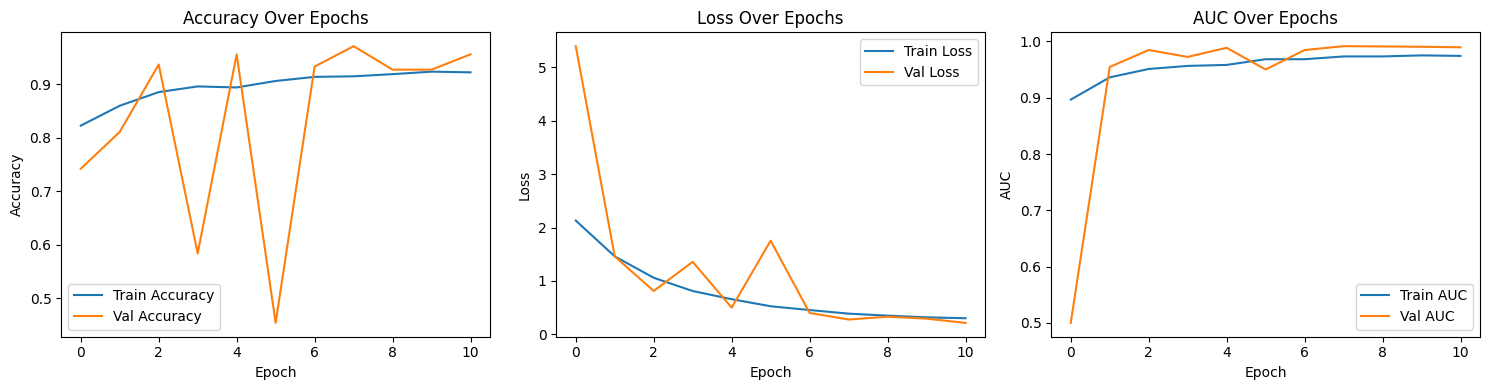

In [36]:
# Plot training curves (loss, accuracy, and AUC)
if baseline_tuned_history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(baseline_tuned_history.history["accuracy"], label="Train Accuracy")
    plt.plot(baseline_tuned_history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(baseline_tuned_history.history["loss"], label="Train Loss")
    plt.plot(baseline_tuned_history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(baseline_tuned_history.history["auc"], label="Train AUC")
    plt.plot(baseline_tuned_history.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

Test ROC-AUC: 0.9512


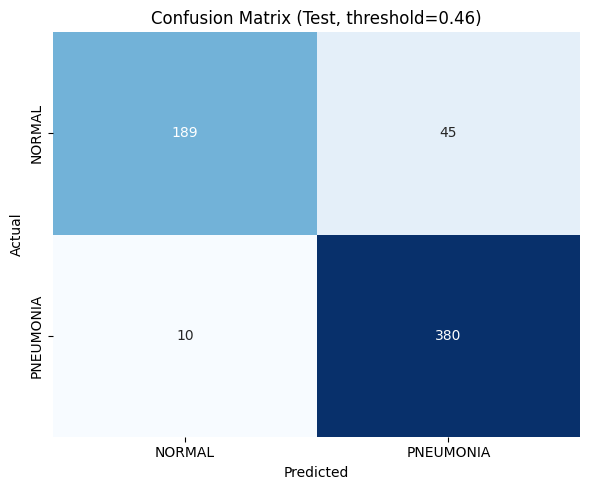

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.95      0.81      0.87       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



In [34]:
# Test set confusion matrix for tuned model
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – Tuned (threshold={baseline_tuned_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

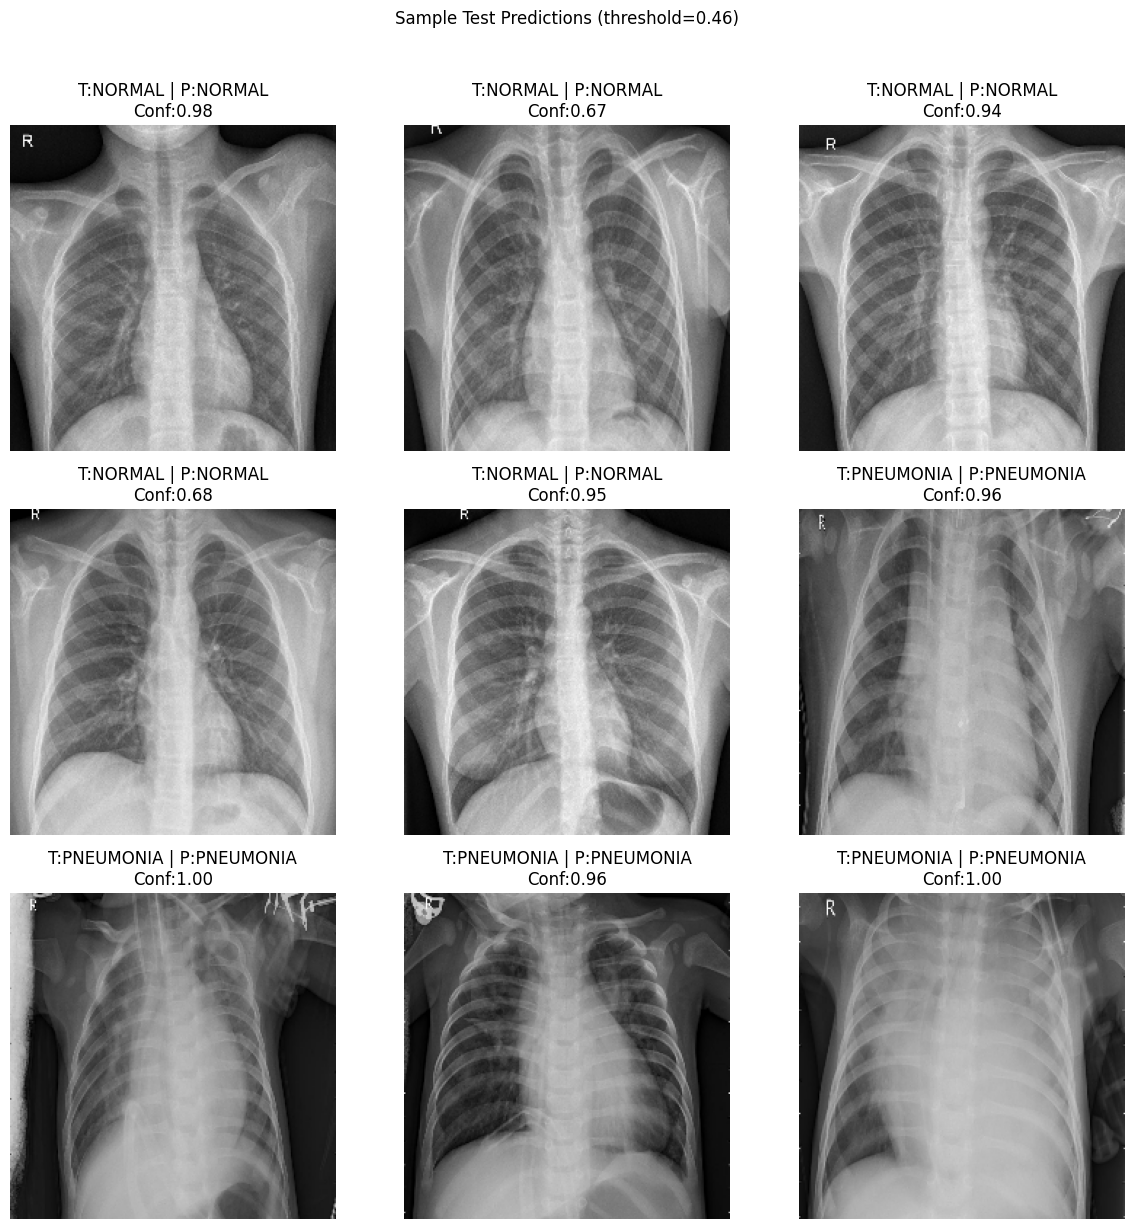

In [35]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = baseline_tuned_model.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()